# Линал 3 раздел

In [220]:
from sympy import *
from IPython.display import *

def geo(m):
    """ Вывод матрицы в формате геолина """
    if m.shape[0] == 1:
        return f'[{', '.join([str(round(m[0, i], 10)) for i in range(m.shape[1])])}]'
    return f'[{'; '.join([', '.join([str(round(m[j, i], 10)) for i in range(m.shape[1])]) for j in range(m.shape[0])])}]'    

def geolin_matrix(s: str, n: int) -> Matrix:
    """ Ввод матрицы по столбцам """
    s = s.replace('\u2212', '-').replace('\u200b', '').split()
    d = MutableDenseMatrix.zeros(n, len(s) // n)
    for i in range(len(s)):
        d[i % n, i // n] = int(s[i])
    return d

def geolin_vector(s: str) -> Matrix:
    """ Ввод вектора """
    s = s.replace('\u2212', '-').replace('\u200b', '').split()
    return Matrix([int(x) for x in s])

In [221]:
""" Нахождение ортонормированного базиса и ортагональной проекции """

def dot(a, b, G): 
    return sympify((a.T * G * b)[0])

def LNZ_basis(vectors):
    matrix = Matrix.hstack(*vectors)
    rank = matrix.rank()
    if rank < len(vectors):
        display(Latex("\nВекторы линейно зависимы. Оставляем базис из", rank, "векторов."))
        column_space = matrix.columnspace()
        vectors = [vec.as_immutable() for vec in column_space]
        display(column_space)
    else:
        display(Latex("\nВсе векторы линейно независимы."))
    return vectors

def _ortho_basis(vectors, G):
    vectors = LNZ_basis(vectors)
    display(Latex("Ортагонализация Грама-Шмидта"))
    ortho_vectors = []
    for i, v in enumerate(vectors):
        u = v.copy()
        
        out = f'$\\tilde{{e}}_{i+1} = e_{i+1}'
        for j, e in enumerate(ortho_vectors):
            coeff = dot(v, e, G) / dot(e, e, G)
            u -= coeff * e
            out += f"- {coeff} * e_{j+1}"
        
        if u.norm() != 0:
            ortho_vectors.append(u)
            out += f" = {latex(u.T)}^T$."
        else:
            out += "= \\vec{0}$ -- исключаем."
        display(Latex(out))
    return ortho_vectors

def orthonormal_basis(vectors, G):
    ortho_vectors = _ortho_basis(vectors, G)
    display(Latex("Нормировка"))
    orthonormal_vectors = []
    for i, u in enumerate(ortho_vectors):
        norm = sqrt(dot(u, u, G))
        e = u / norm
        orthonormal_vectors.append(e)
        display(Latex(f"$\\tilde{{\\tilde{{e}}}}_{i+1} = \\frac{{\\tilde{{e}}}}{{{norm}}} = {latex(e.T)}^T$"))
    basis = Matrix.hstack(*orthonormal_vectors)
    display(Latex("Ортонормированный базис"), basis)
    return orthonormal_vectors

def projection(basis, y, G):
    display(Latex("Вычислим проекцию"))
    projection = Matrix.zeros(y.rows, 1)
    out = "p = "
    for i, e in enumerate(basis):
        projection += e * dot(y, e, G)
        out += f"{dot(y, e, G)} * e_{i}"
    p = simplify(projection)
    out += f"= {latex(p.T)}^T"
    display(Math(out))
    return p

In [222]:
""" Метод Якоби """

def principal_minors(Q: Matrix) -> list:
    display(Latex("Главные миноры"))
    pms = []
    for i in range(1, Q.rows+1):
        pm = Q[:i, :i].det()
        pms.append(pm)
        display(Math(f"\\Delta_{i} = {latex(Q[:i, :i])} = {pm}"))
        if pm == 0 and i != Q.rows:
            display(Latex("Нулевой минор!"))
            return None
    return pms 

def jacobi_eigen(Q: Matrix) -> list:
    pms = principal_minors(Q)
    if pms is None:
        eigen = Q.eigenvals()
        display(Latex(f"Находим собственные числа стандартным образом: {eigen}"))
        return eigen
    eigen_values = [pms[0]]
    display(Latex("Коэффициенты в разложении Якоби (собственные числа)"))
    display(Math(f"\\alpha_1 = \\Delta_1 = {eigen_values[0]}"))
    for i in range(1, Q.rows):
        eig = pms[i] / pms[i-1]
        eigen_values.append(eig)
        display(Math(f"\\alpha_{i+1} = \\frac{{\\Delta_{i+1}}}{{\\Delta_{i}}} = {eig}"))
    return eigen_values

def signature(eigen: list):
    p, q =sum(1 for x in eigen if x > 0), sum(1 for x in eigen if x < 0)
    display(Latex(f"Cигнатура: ({p}, {q})"))
    return p, q

# ДЗ 3.1

### Задание 1

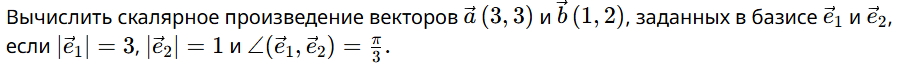

In [223]:
a = Matrix([3, 3])
b = Matrix([1, 2])
e1 = 3
e2 = 1
alpha = pi/3

G = Matrix([
    [e1 * e1, e1 * e2 * cos(alpha)],
    [e2 * e1 * cos(alpha), e2 * e2]
])
display("Матрица Грамма", G)

product = a.T @ G @ b

print('Ответ:')
print(product[0, 0])

'Матрица Грамма'

Matrix([
[  9, 3/2],
[3/2,   1]])

Ответ:
93/2


### Задание 2

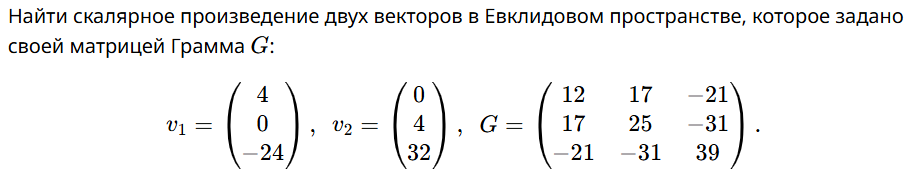

In [224]:
v1 = geolin_vector("4 0 -24")
v2 = geolin_vector("0 4 32")
G = geolin_matrix("12 17 -21 17 25 -31 -21 -31 39", 3)

product = v1.T @ G @ v2

print('Ответ:')
print(product[0, 0])

Ответ:
-29392


### Задание 3

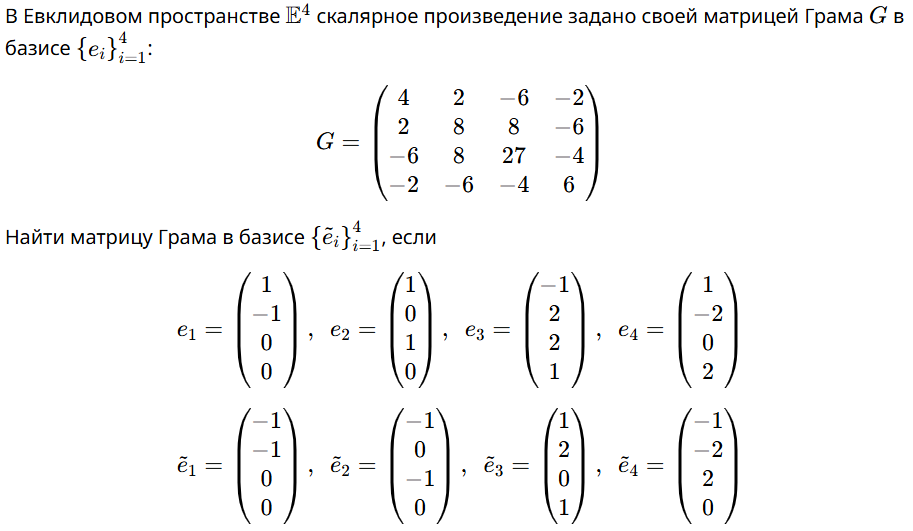

In [225]:
G = geolin_matrix("4 2 -6 -2 2 8 8 -6 -6 8 27 -4 -2 -6 -4 6", 4)
old_basis = geolin_matrix("1 -1 0 0 1 0 1 0 -1 2 2 1 1 -2 0 2", 4)
new_basis = geolin_matrix("-1 -1 0 0 -1 0 -1 0 1 2 0 1 -1 -2 2 0", 4)

C = old_basis.inv() @ new_basis
display("Матрица перехода", C)

new_G = C.T @ G @ C
display("Матрица грамма в новом базисе", new_G)

print("Ответ:")
print(geo(new_G))

'Матрица перехода'

Matrix([
[13,  0, -24,  32],
[-8, -1,  14, -18],
[ 4,  0,  -7,  10],
[-2,  0,   4,  -5]])

'Матрица грамма в новом базисе'

Matrix([
[  68,  -6, -142,  174],
[  -6,   8,   16,  -30],
[-142,  16,  299, -370],
[ 174, -30, -370,  474]])

Ответ:
[68, -6, -142, 174; -6, 8, 16, -30; -142, 16, 299, -370; 174, -30, -370, 474]


### Задание 4

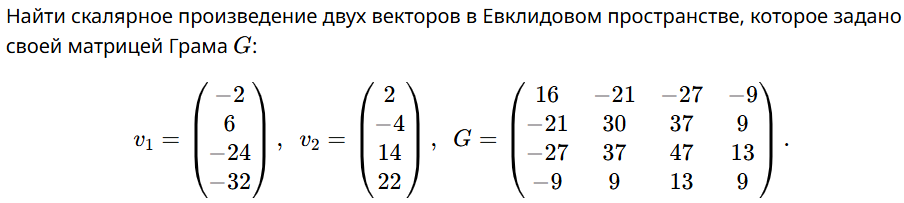

In [226]:
v1 = geolin_vector("-2 6 -24 -32")
v2 = geolin_vector("2 -4 14 22")
G = geolin_matrix("16 -21 -27 -9 -21 30 37 9 -27 37 47 13 -9 9 13 9", 4)

product = v1.T @ G @ v2

print('Ответ:')
print(product[0, 0])

Ответ:
-23996


### Задание 5

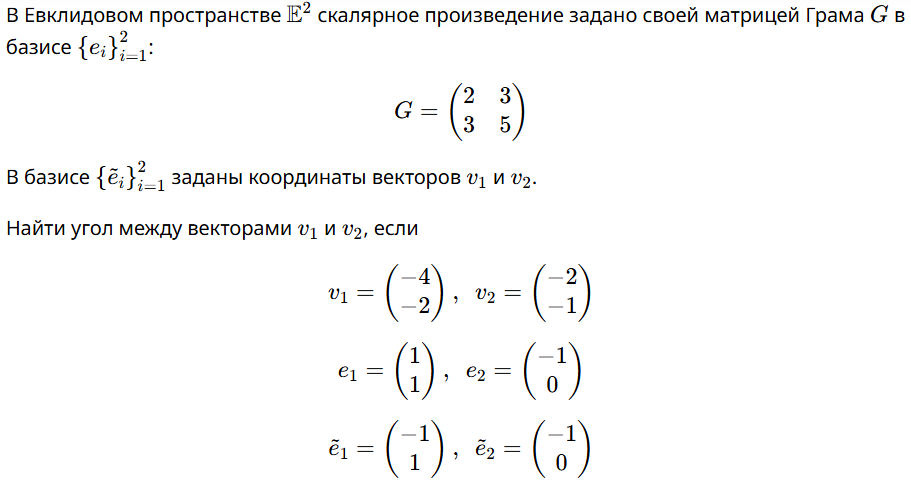

$<a, b> = |a| \cdot |b| \cdot \cos\alpha = C^T * G * C$

In [227]:
G = geolin_matrix("2 3 3 5", 2)
v1 = geolin_vector("-4 -2")
v2 = geolin_vector("-2 -1")
old_basis = geolin_matrix("1 1 -1 0", 2)
new_basis = geolin_matrix("-1 1 -1 0", 2)

C = old_basis.inv() @ new_basis
display("Матрица перехода", C)

new_G = C.T @ G @ C
display("Матрица грамма в новом базисе", new_G)

product = (v1.T @ new_G @ v2)[0, 0]
display(f'Скалярное произведение = {product}')

v1_norm = sqrt((v1.T @ new_G @ v1)[0])
v2_norm = sqrt((v2.T @ new_G @ v2)[0])
display(f"Длины векторов: {v1_norm} и {v2_norm}")

cos_alpha = product / (v1_norm * v2_norm)
display(f'Косинус угла: {cos_alpha}')

print('Ответ:')
print(acos(cos_alpha).evalf())

'Матрица перехода'

Matrix([
[1, 0],
[2, 1]])

'Матрица грамма в новом базисе'

Matrix([
[34, 13],
[13,  5]])

'Скалярное произведение = 386'

'Длины векторов: 2*sqrt(193) и sqrt(193)'

'Косинус угла: 1'

Ответ:
0


### Задание 6

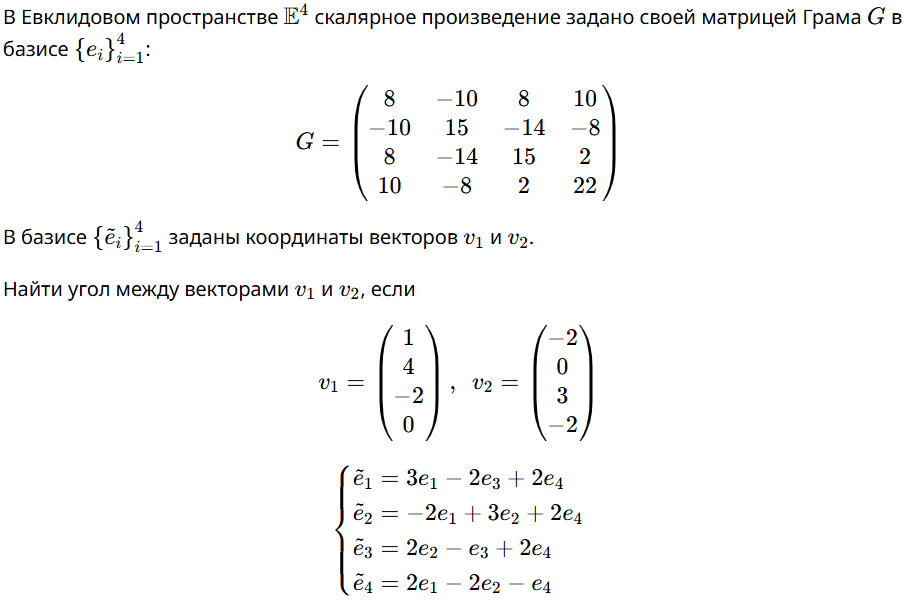

Столбцы матрицы перехода определяются коэффициентами в строках системы.

In [228]:
G = geolin_matrix("8 -10 8 10 -10 15 -14 -8 8 -14 15 2 10 -8 2 22", 4)
v1 = geolin_vector("1 4 -2 0")
v2 = geolin_vector("-2 0 3 -2")
C = geolin_matrix("3 0 -2 2 -2 3 0 2 0 2 -1 2 2 -2 0 -1", 4)

display("Матрица перехода", C)

new_G = C.T @ G @ C
display("Матрица грамма в новом базисе", new_G)

product = (v1.T @ new_G @ v2)[0, 0] 
display(f'Скалярное произведение = {product}')

v1_norm = sqrt((v1.T @ new_G @ v1)[0])
v2_norm = sqrt((v2.T @ new_G @ v2)[0])
display(f"Длины векторов: {v1_norm} и {v2_norm}")

cos_alpha = product / (v1_norm * v2_norm)
display(f'Косинус угла: {cos_alpha}')

print('Ответ:')
print(acos(cos_alpha).evalf())

'Матрица перехода'

Matrix([
[ 3, -2,  0,  2],
[ 0,  3,  2, -2],
[-2,  0, -1,  0],
[ 2,  2,  2, -1]])

'Матрица грамма в новом базисе'

Matrix([
[228,   30, 106,   22],
[ 30,  199, 152, -150],
[106,  152, 147,  -98],
[ 22, -150, -98,  122]])

'Скалярное произведение = 1752'

'Длины векторов: 2*sqrt(346) и sqrt(2803)'

'Косинус угла: 438*sqrt(969838)/484919'

Ответ:
0.474508222018027


### Задание 7

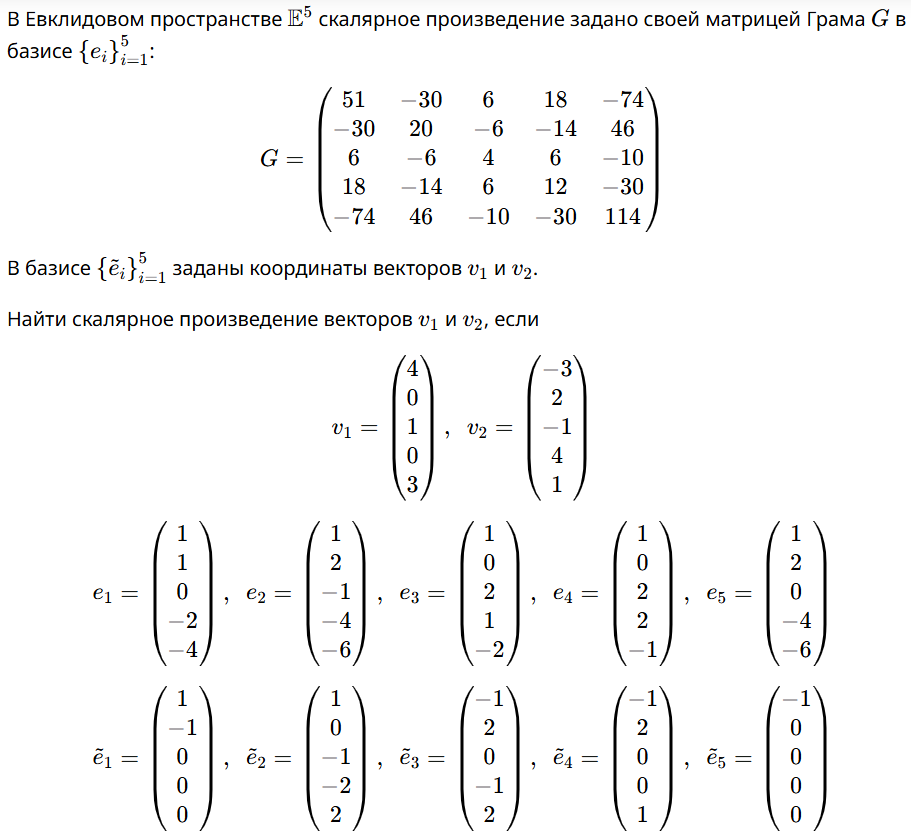

In [229]:
G = geolin_matrix("51 -30 6 18 -74 -30 20 -6 -14 46 6 -6 4 6 -10 18 -14 6 12 -30 -74 46 -10 -30 114", 5)
v1 = geolin_vector("4 0 1 0 3")
v2 = geolin_vector("-3 2 -1 4 1")
old_basis = geolin_matrix("1 1 0 -2 -4 1 2 -1 -4 -6 1 0 2 1 -2 1 0 2 2 -1 1 2 0 -4 -6", 5)
new_basis = geolin_matrix("1 -1 0 0 0 1 0 -1 -2 2 -1 2 0 -1 2 -1 2 0 0 1 -1 0 0 0 0", 5)

C = old_basis.inv() @ new_basis
display("Матрица перехода", C)

new_G = C.T @ G @ C
display("Матрица грамма в новом базисе", new_G)

product = (v1.T @ new_G @ v2)[0, 0] 
display(f'Скалярное произведение = {product}')

print('Ответ:')
print(product)

'Матрица перехода'

Matrix([
[ 7,  14, -2, -6, -6],
[-4, -11, -2,  2,  4],
[-2, -10, -5, -2,  4],
[ 0,   4,  4,  3, -2],
[ 0,   4,  4,  2, -1]])

'Матрица грамма в новом базисе'

Matrix([
[ 4251,  6940, -2712, -4316, -3328],
[ 6940, 11344, -4414, -7042, -5434],
[-2712, -4414,  1744,  2758,  2122],
[-4316, -7042,  2758,  4384,  3378],
[-3328, -5434,  2122,  3378,  2606]])

'Скалярное произведение = -16958'

Ответ:
-16958


### Задание 8

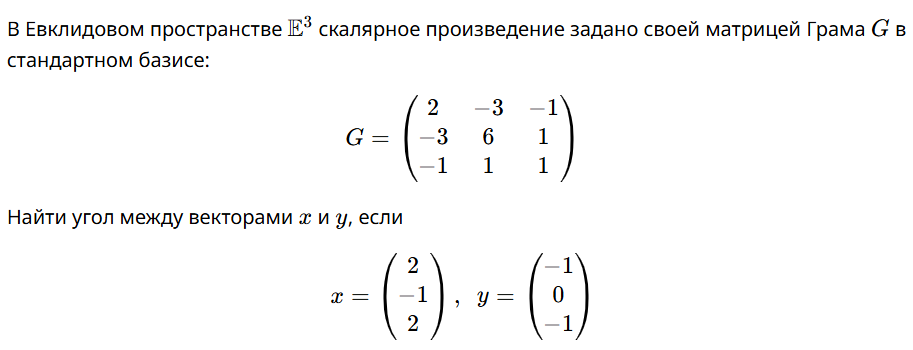

In [230]:
G = geolin_matrix("2 -3 -1 -3 6 1 -1 1 1", 3)
x = geolin_vector("2 -1 2")
y = geolin_vector("-1 0 -1")

product = (x.T @ G @ y)[0, 0] 
display(f'Скалярное произведение = {product}')

x_norm = sqrt((x.T @ G @ x)[0])
y_norm = sqrt((y.T @ G @ y)[0])
display(f"Длины векторов: {x_norm} и {y_norm}")

cos_alpha = product / (x_norm * y_norm)
display(f'Косинус угла: {cos_alpha}')

print('Ответ:')
print(acos(cos_alpha).evalf())

'Скалярное произведение = -4'

'Длины векторов: 3*sqrt(2) и 1'

'Косинус угла: -2*sqrt(2)/3'

Ответ:
2.80175574413567


### Задание 9

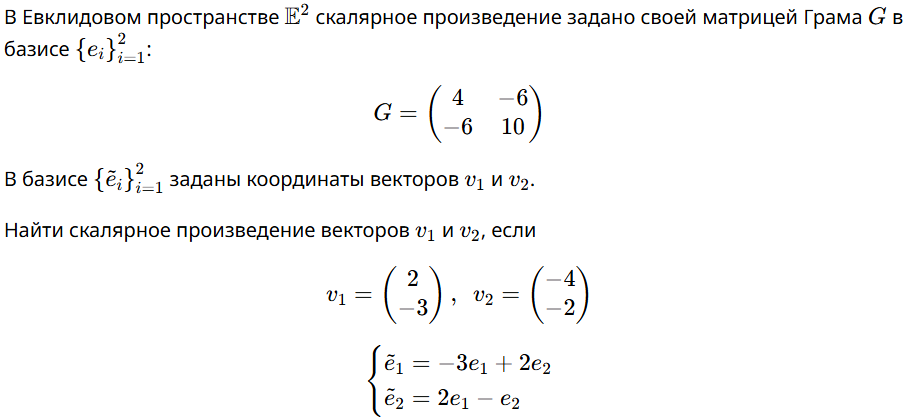

In [231]:
G = geolin_matrix("4 -6 -6 10", 2)
v1 = geolin_vector("2 -3")
v2 = geolin_vector("-4 -2")
C = geolin_matrix("-3 2 2 -1", 2)

display("Матрица перехода", C)

new_G = C.T @ G @ C
display("Матрица грамма в новом базисе", new_G)

product = (v1.T @ new_G @ v2)[0, 0] 
display(f'Скалярное произведение = {product}')

print('Ответ:')
print(product)

'Матрица перехода'

Matrix([
[-3,  2],
[ 2, -1]])

'Матрица грамма в новом базисе'

Matrix([
[148, -86],
[-86,  50]])

'Скалярное произведение = -1572'

Ответ:
-1572


### Задание 10

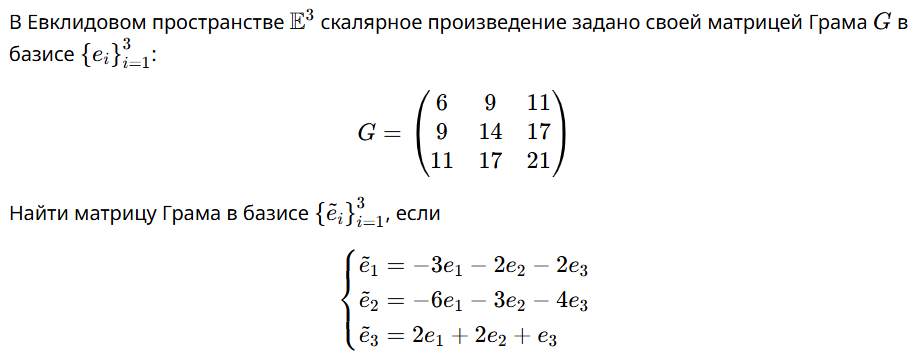

In [232]:
G = geolin_matrix("6 9 11 9 14 17 11 17 21", 3)
C = geolin_matrix("-3 -2 -2 -6 -3 -4 2 2 1", 3)

display("Матрица перехода", C)

new_G = C.T @ G @ C
display("Матрица грамма в новом базисе", new_G)

print('Ответ:')
print(geo(new_G))

'Матрица перехода'

Matrix([
[-3, -6, 2],
[-2, -3, 2],
[-2, -4, 1]])

'Матрица грамма в новом базисе'

Matrix([
[ 570, 1051, -403],
[1051, 1938, -743],
[-403, -743,  285]])

Ответ:
[570, 1051, -403; 1051, 1938, -743; -403, -743, 285]


# ДЗ 3.2

### Задание 1

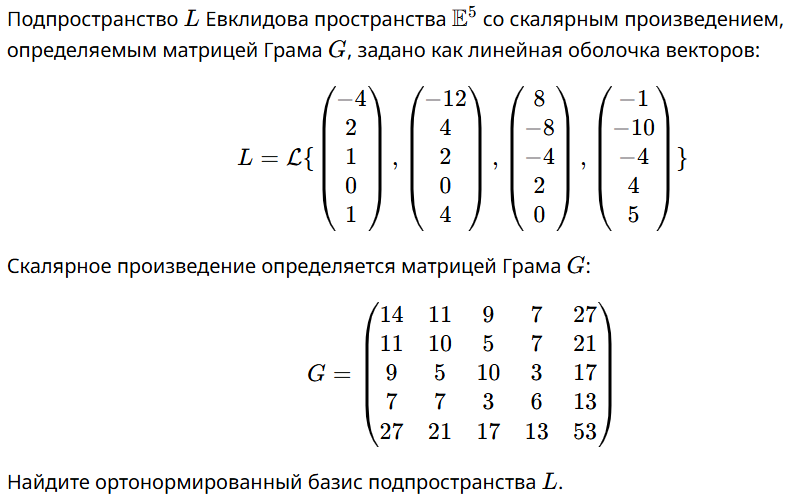

In [233]:
G = geolin_matrix("14 11 9 7 27 11 10 5 7 21 9 5 10 3 17 7 7 3 6 13 27 21 17 13 53", 5)
vectors = [
    geolin_vector("-4 2 1 0 1"),
    geolin_vector("-12 4 2 0 4"),
    geolin_vector("8 -8 -4 2 0"),
    geolin_vector("-1 -10 -4 4 5")
]

basis = orthonormal_basis(vectors, G)
print(geo(Matrix.hstack(*basis).T))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Matrix([
[-4, -2,  6,  7],
[ 2,  0, -4, -6],
[ 1,  0, -2, -2],
[ 0,  0,  1,  2],
[ 1,  1, -1, -1]])

[-4, 2, 1, 0, 1; -2, 0, 0, 0, 1; 6, -4, -2, 1, -1; 7, -6, -2, 2, -1]


### Задание 2

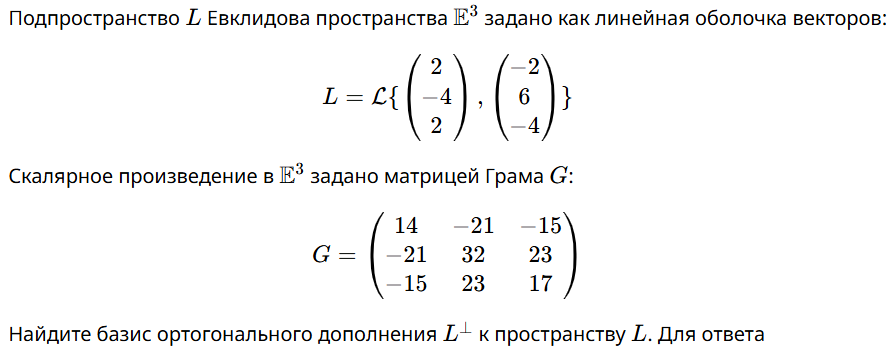

In [234]:
G = geolin_matrix("14 -21 -15 -21 32 23 -15 23 17", 3)
vectors = [
    geolin_vector("2 -4 2"),
    geolin_vector("-2 6 -4"),
]

# Создаем матрицу системы уравнений для ортогональности
A = Matrix.hstack(*[(G * v) for v in vectors]).T
# Решаем систему уравнений
solution = A.nullspace()

display(Latex("Система уравнений $A \\cdot x = \\langle x, v_i \\rangle = \\vec{0}$"), A)

basis = Matrix.hstack(*solution)
display(Latex("Базис ортогонального дополнения"), basis)
print(geo(basis.T))

<IPython.core.display.Latex object>

Matrix([
[ 82, -124, -88],
[-94,  142, 100]])

<IPython.core.display.Latex object>

Matrix([
[-8],
[-6],
[ 1]])

[-8, -6, 1]


### Задание 3

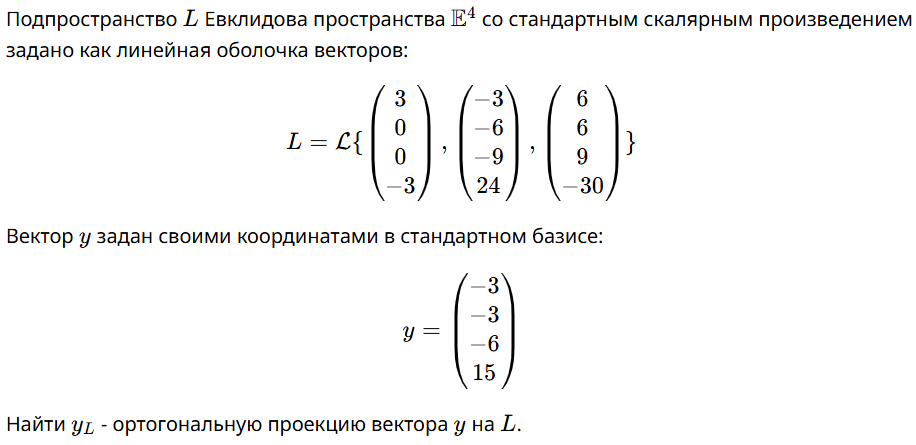

In [235]:
vectors = [
    geolin_vector("3 0 0 -3"),
    geolin_vector("-3 -6 -9 24"),
    geolin_vector("6 6 9 -30")
]
y = geolin_vector("-3 -3 -6 15")

G = eye(4)
basis = orthonormal_basis(vectors, G)
y_L = projection(basis, y, G)
print(geo(y_L.T))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

Matrix([
[ sqrt(2)/2,  7*sqrt(6)/30,     -sqrt(39)/15],
[         0, -2*sqrt(6)/15, -14*sqrt(39)/195],
[         0,    -sqrt(6)/5,   -7*sqrt(39)/65],
[-sqrt(2)/2,  7*sqrt(6)/30,     -sqrt(39)/15]])

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

[-3, -3.6923076923, -5.5384615385, 15]


### Задание 4

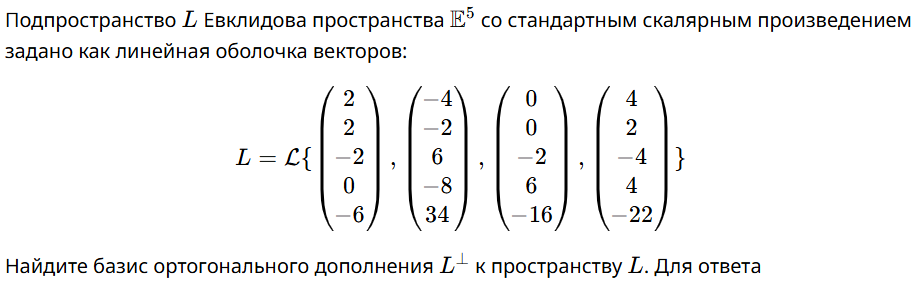

In [236]:
vectors = [
    geolin_vector("2 2 -2 0 -6"),
    geolin_vector("-4 -2 6 -8 34"),
    geolin_vector("0 0 -2 6 -16"),
    geolin_vector("4 2 -4 4 -22"),
]

G = eye(5)

# Создаем матрицу системы уравнений для ортогональности
A = Matrix.hstack(*[(G * v) for v in vectors]).T
# Решаем систему уравнений
solution = A.nullspace()

display(Latex("Система уравнений $A \\cdot x = \\langle x, v_i \\rangle = \\vec{0}$"), A)

basis = Matrix.hstack(*solution)
display(Latex("Базис ортогонального дополнения"), basis)
print(geo(basis.T))

<IPython.core.display.Latex object>

Matrix([
[ 2,  2, -2,  0,  -6],
[-4, -2,  6, -8,  34],
[ 0,  0, -2,  6, -16],
[ 4,  2, -4,  4, -22]])

<IPython.core.display.Latex object>

Matrix([
[ 2],
[-1],
[-2],
[ 2],
[ 1]])

[2, -1, -2, 2, 1]


### Задание 5

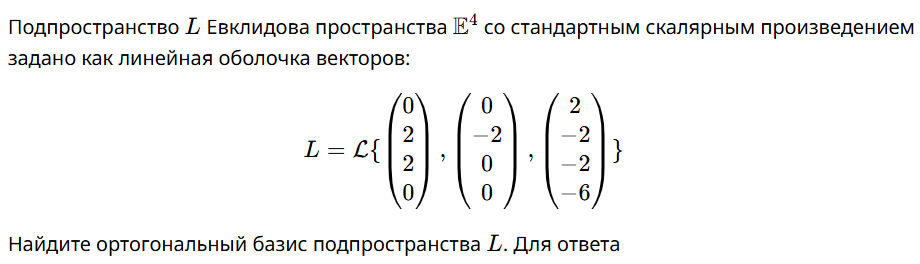

In [237]:
vectors = [
    geolin_vector("0 2 2 0"),
    geolin_vector("0 -2 0 0"),
    geolin_vector("2 -2 -2 -6"),
]

G = eye(4)

basis = orthonormal_basis(vectors, G)
print(geo(Matrix.hstack(*basis).T))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Matrix([
[        0,          0,    sqrt(10)/10],
[sqrt(2)/2, -sqrt(2)/2,              0],
[sqrt(2)/2,  sqrt(2)/2,              0],
[        0,          0, -3*sqrt(10)/10]])

[0, 0.7071067812, 0.7071067812, 0; 0, -0.7071067812, 0.7071067812, 0; 0.3162277660, 0, 0, -0.9486832981]


### Задание 6

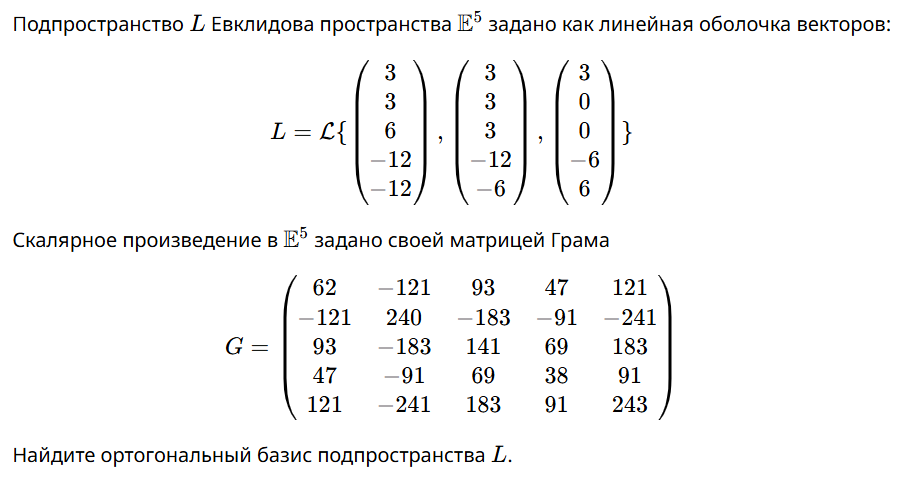

In [238]:
G = geolin_matrix("62 -121 93 47 121 -121 240 -183 -91 -241 93 -183 141 69 183 47 -91 69 38 91 121 -241 183 91 243", 5)
vectors = [
    geolin_vector("3 3 6 -12 -12"),
    geolin_vector("3 3 3 -12 -6"),
    geolin_vector("3 0 0 -6 6")
]

basis = orthonormal_basis(vectors, G)
print(geo(Matrix.hstack(*basis).T))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Matrix([
[sqrt(1238)/2476,  341*sqrt(2028463)/4056926,  7107*sqrt(2939881902)/1959921268],
[sqrt(1238)/2476,  341*sqrt(2028463)/4056926, -4895*sqrt(2939881902)/5879763804],
[sqrt(1238)/1238, -278*sqrt(2028463)/2028463, 22067*sqrt(2939881902)/2939881902],
[-sqrt(1238)/619, -682*sqrt(2028463)/2028463, -8213*sqrt(2939881902)/1469940951],
[-sqrt(1238)/619,  556*sqrt(2028463)/2028463, -8959*sqrt(2939881902)/1469940951]])

[0.0142105106, 0.0142105106, 0.0284210211, -0.0568420423, -0.0568420423; 0.1197128687, 0.1197128687, -0.1951916569, -0.4788514749, 0.3903833139; 0.1966131821, -0.0451396054, 0.4069849528, -0.3029471534, -0.3304643307]


### Задание 7

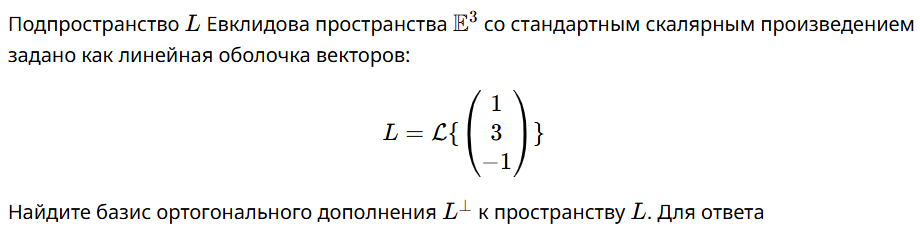

In [239]:
vectors = [
    geolin_vector("1 3 -1")
]

G = eye(3)

# Создаем матрицу системы уравнений для ортогональности
A = Matrix.hstack(*[(G * v) for v in vectors]).T
# Решаем систему уравнений
solution = A.nullspace()

display(Latex("Система уравнений $A \\cdot x = \\langle x, v_i \\rangle = \\vec{0}$"), A)

basis = Matrix.hstack(*solution)
display(Latex("Базис ортогонального дополнения"), basis)
print(geo(basis.T))

<IPython.core.display.Latex object>

Matrix([[1, 3, -1]])

<IPython.core.display.Latex object>

Matrix([
[-3, 1],
[ 1, 0],
[ 0, 1]])

[-3, 1, 0; 1, 0, 1]


### Задание 8

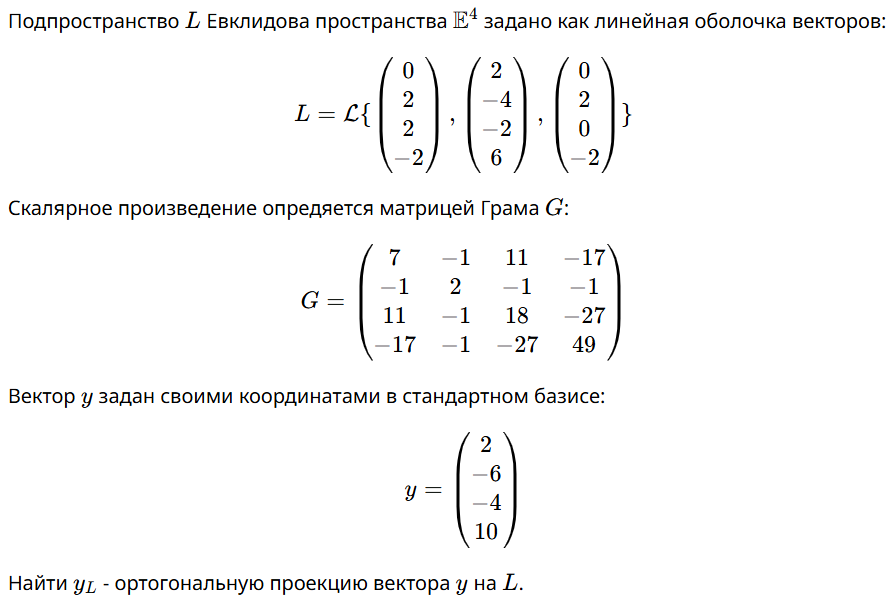

In [240]:
G = geolin_matrix("7 -1 11 -17 -1 2 -1 -1 11 -1 18 -27 -17 -1 -27 49", 4)
vectors = [
    geolin_vector("0 2 2 -2"),
    geolin_vector("2 -4 -2 6"),
    geolin_vector("0 2 0 -2")
]
y = geolin_vector("2 -6 -4 10")

basis = orthonormal_basis(vectors, G)
y_L = projection(basis, y, G)
print(geo(y_L.T))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

Matrix([
[             0,     sqrt(3239)/158,  85*sqrt(1659)/1106],
[ sqrt(123)/123,    sqrt(3239)/3239,   13*sqrt(1659)/237],
[ sqrt(123)/123, 43*sqrt(3239)/6478, -37*sqrt(1659)/3318],
[-sqrt(123)/123, 39*sqrt(3239)/6478,  73*sqrt(1659)/3318]])

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

[6.8571428571, -4, -5.5714285714, 10.8571428571]


### Задание 9

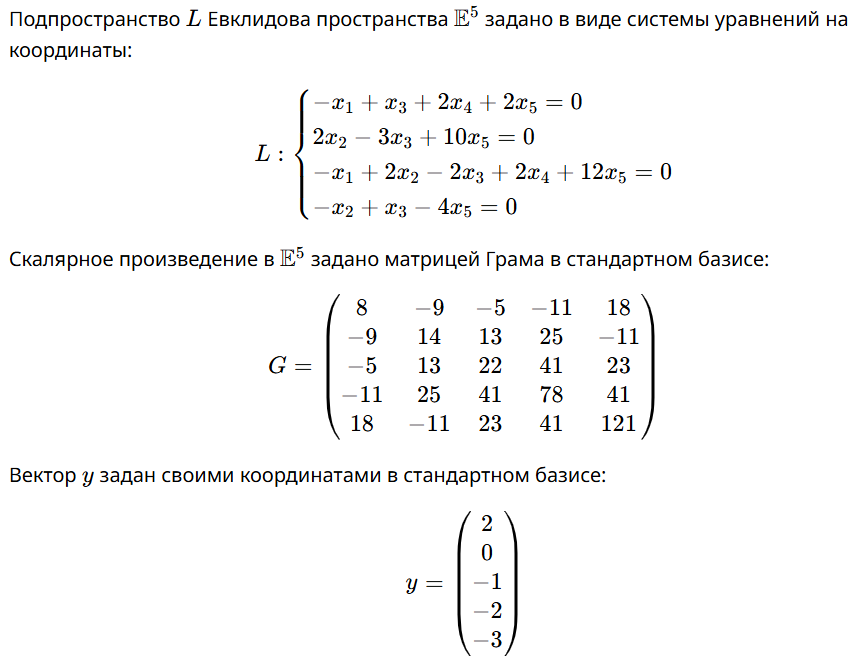

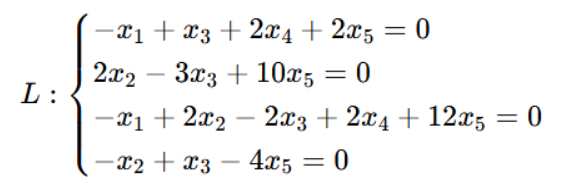

Вводим построчно коэффициенты в матрицу $A$.

In [241]:
G = geolin_matrix("8 -9 -5 -11 18 -9 14 13 25 -11 -5 13 22 41 23 -11 25 41 78 41 18 -11 23 41 121", 5)
y = geolin_vector("2 0 -1 -2 -3")
A = geolin_matrix("-1 0 1 2 2   0 2 -3 0 10   -1 2 -2 2 12   0 -1 1 0 -4", 5)

vectors = A.T.nullspace()

basis = orthonormal_basis(vectors, G)
y_L = projection(basis, y, G)
print(geo(y_L.T))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

Matrix([
[sqrt(66)/33,   -13*sqrt(1369698)/684849],
[          0,     -2*sqrt(1369698)/20753],
[          0,      2*sqrt(1369698)/20753],
[sqrt(66)/66, -145*sqrt(1369698)/1369698],
[          0,        sqrt(1369698)/20753]])

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

[-11.0975762540, -0.3415409820, 0.3415409820, -5.8903291090, 0.1707704910]


### Задание 10

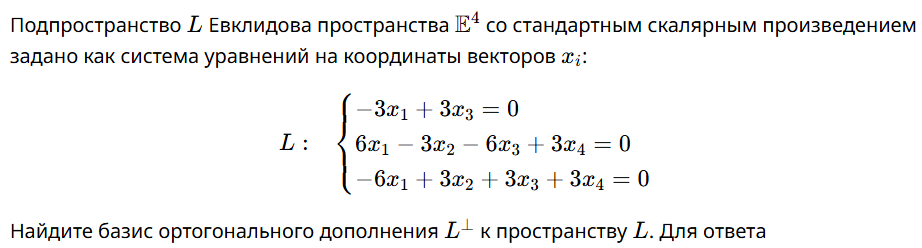

In [242]:
A = geolin_matrix("-3 0 3 0   6 -3 -6 3   -6 3 3 3", 4)

vectors = A.T.nullspace()

G = eye(4)

# Создаем матрицу системы уравнений для ортогональности
A = Matrix.hstack(*[(G * v) for v in vectors]).T
# Решаем систему уравнений
solution = A.nullspace()

display(Latex("Система уравнений $A \\cdot x = \\langle x, v_i \\rangle = \\vec{0}$"), A)

basis = Matrix.hstack(*solution)
display(Latex("Базис ортогонального дополнения"), basis)
print(geo(basis.T))

<IPython.core.display.Latex object>

Matrix([[2, 1, 2, 1]])

<IPython.core.display.Latex object>

Matrix([
[-1/2, -1, -1/2],
[   1,  0,    0],
[   0,  1,    0],
[   0,  0,    1]])

[-0.5000000000, 1, 0, 0; -1, 0, 1, 0; -0.5000000000, 0, 0, 1]


# ДЗ 3.3

### Задание 1

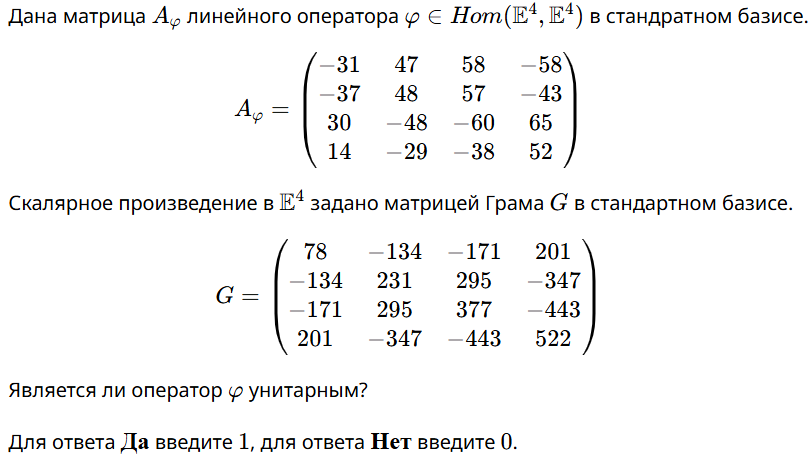

In [243]:
A = geolin_matrix("−31 −37 30 14 47 48 −48 −29 58 57 −60 −38 −58 −43 65 52", 4)
G = geolin_matrix("78 −134 −171 201 ​ −134 231 295 −347 ​ −171 295 377 −443 ​ 201 −347 −443 522", 4)

Ai = A.inv()
display(Latex("$A^{-1}$"), Ai)
Ad = G.inv() * A.T * G
display(Latex("$A^\\dagger = G^{-1} \\times A^T \\times G$"), Ad)
display(Latex("Ответ"))
print(1 if Ai == Ad else 0)

<IPython.core.display.Latex object>

Matrix([
[ 15,  -16,  -14,   21],
[100, -150, -182,  215],
[-79,  125,  157, -181],
[ -6,   12,   17,  -18]])

<IPython.core.display.Latex object>

Matrix([
[-229,  408,  529,  -608],
[-565, 1006, 1306, -1495],
[ 183, -326, -423,   485],
[-131,  233,  303,  -345]])

<IPython.core.display.Latex object>

0


### Задание 2

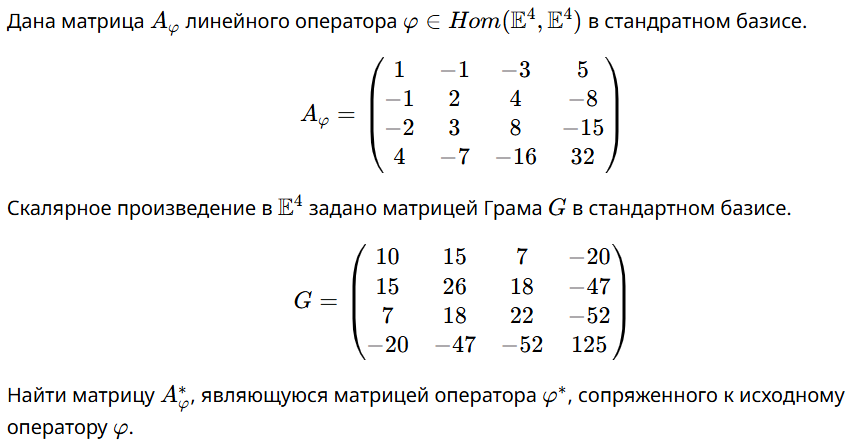

In [244]:
A = geolin_matrix("1 −1 −2 4 −1 2 3 −7 −3 4 8 −16 5 −8 −15 32", 4)
G = geolin_matrix("10 15 7 −20 15 26 18 −47 7 18 22 −52 −20 −47 −52 125", 4)

Ad = G.inv() * A.T * G
display(Latex("$A^\\dagger = G^{-1} \\times A^T \\times G$"), Ad)
display(Latex("Ответ"))
print(geo(Ad))

<IPython.core.display.Latex object>

Matrix([
[-12928, -30601, -34145,  81958],
[ 13962,  33056,  36893, -88551],
[ 12693,  30085,  33616, -80672],
[  8455,  20033,  22376, -53701]])

<IPython.core.display.Latex object>

[-12928, -30601, -34145, 81958; 13962, 33056, 36893, -88551; 12693, 30085, 33616, -80672; 8455, 20033, 22376, -53701]


### Задание 3

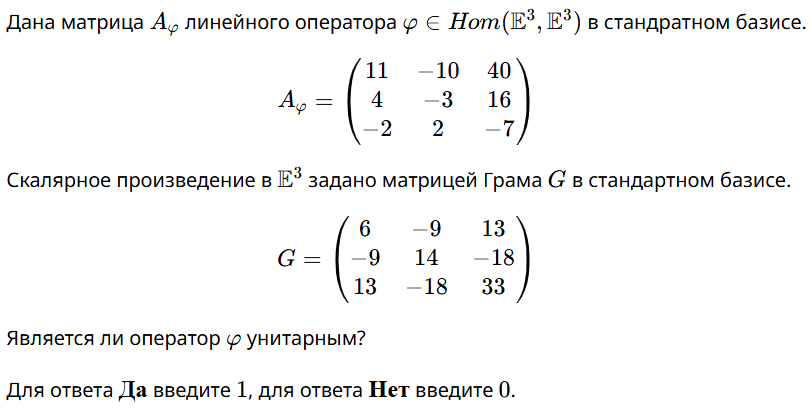

In [245]:
A = geolin_matrix("11 4 −2 −10 −3 2 40 16 −7", 3)
G = geolin_matrix("6 −9 13 −9 14 −18 13 −18 33", 3)

Ai = A.inv()
display(Latex("$A^{-1}$"), Ai)
Ad = G.inv() * A.T * G
display(Latex("$A^\\dagger = G^{-1} \\times A^T \\times G$"), Ad)
display(Latex("Ответ"))
print(1 if Ai == Ad else 0)

<IPython.core.display.Latex object>

Matrix([
[11, -10, 40],
[ 4,  -3, 16],
[-2,   2, -7]])

<IPython.core.display.Latex object>

Matrix([
[11, -10, 40],
[ 4,  -3, 16],
[-2,   2, -7]])

<IPython.core.display.Latex object>

1


### Задание 4

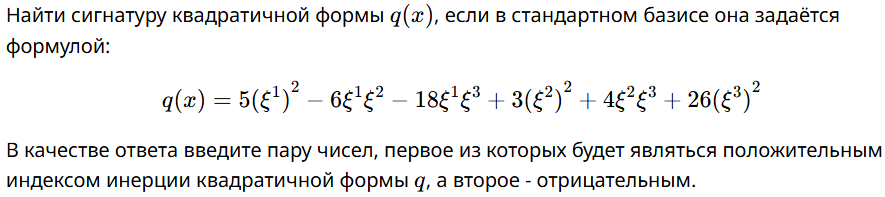

In [246]:
Q = Matrix([
    [5, -3, -9],
    [-3, 3, 2],
    [-9, 2, 26]
])
p, q = signature(jacobi_eigen(Q))
display(Latex("Ответ"))
print(f"[{p}, {q}]")

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

[3, 0]


### Задание 5

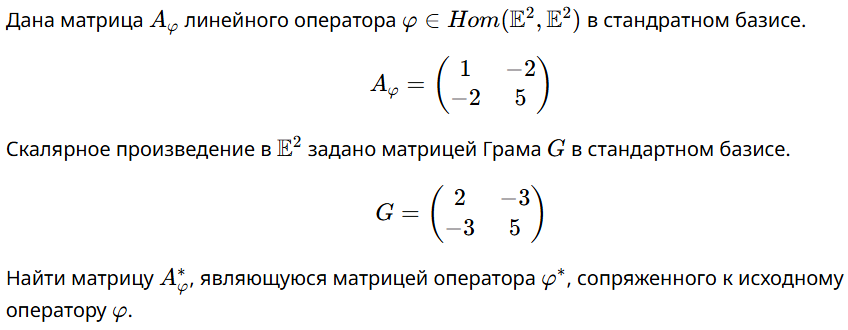

In [248]:
A = geolin_matrix("1 -2 -2 5", 2)
G = geolin_matrix("2 -3 -3 5", 2)

Ad = G.inv() * A.T * G
display(Latex("$A^\\dagger = G^{-1} \\times A^T \\times G$"), Ad)
display(Latex("Ответ"))
print(geo(Ad))

<IPython.core.display.Latex object>

Matrix([
[-17, 28],
[-14, 23]])

<IPython.core.display.Latex object>

[-17, 28; -14, 23]


### Задание 6

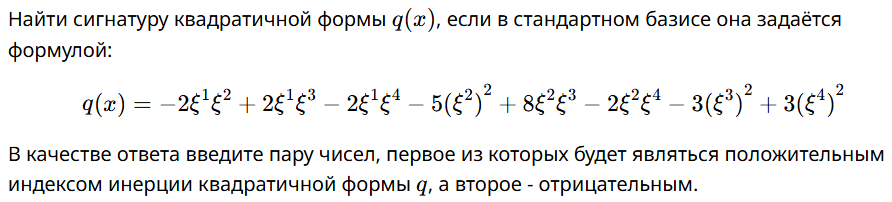

In [247]:
Q = Matrix([
    [0, -1, 1, -1],
    [-1, -5, 4, -1],
    [1, 4, -3, 0],
    [-1, -1, 0, 3]
])
p, q = signature(jacobi_eigen(Q))
display(Latex("Ответ"))
print(f"[{p}, {q}]")

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

[1, 1]


### Задание 7

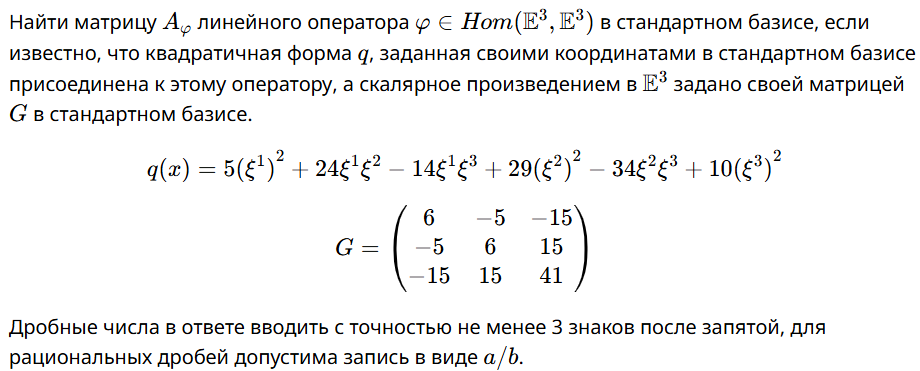

In [251]:
Q = Matrix([
    [5, 12, -7],
    [12, 29, -17],
    [-7, -17, 10]
])
G = geolin_matrix("6 −5 −15 −5 6 15 −15 15 41", 3)

A = G.inv() * Q
display(Latex("$A^\\varphi = G^{-1} \\times Q$"), A)
display(Latex("Ответ"))
print(geo(A))

<IPython.core.display.Latex object>

Matrix([
[-240, -583,  343],
[ 257,  624, -367],
[-182, -442,  260]])

<IPython.core.display.Latex object>

[-240, -583, 343; 257, 624, -367; -182, -442, 260]


### Задание 9

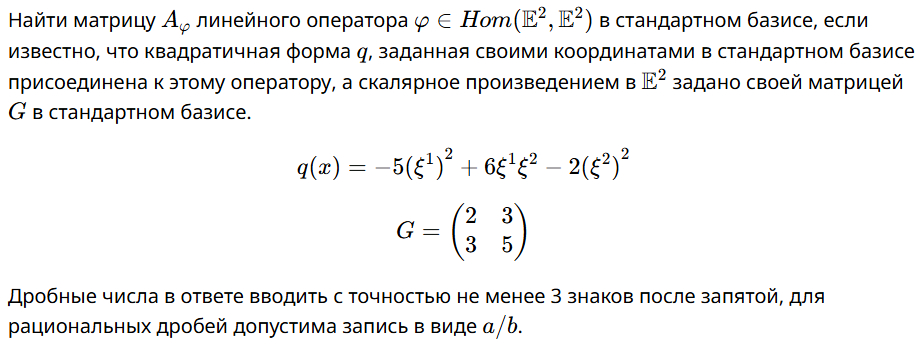

In [252]:
Q = Matrix([
    [-5, 3],
    [3, -2]
])
G = geolin_matrix("2 3 3 5", 2)

A = G.inv() * Q
display(Latex("$A^\\varphi = G^{-1} \\times Q$"), A)
display(Latex("Ответ"))
print(geo(A))

<IPython.core.display.Latex object>

Matrix([
[-34,  21],
[ 21, -13]])

<IPython.core.display.Latex object>

[-34, 21; 21, -13]
